Import Library

In [1]:
from google_play_scraper import app, reviews, Sort, reviews_all

import csv
import numpy as np
np.random.seed(42)
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import re
import string
import requests
from io import StringIO
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import nltk
nltk.download('punkt')
nltk.download('stopwords')

import tensorflow as tf
from wordcloud import WordCloud
from imblearn.over_sampling import SMOTE
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Conv1D, GlobalMaxPooling1D, Bidirectional

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Alls\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alls\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Data Scraping

In [2]:
# Kode Scraping tidak digunakan karena import dari CSV
'''
scrapreview, _ = reviews(
    'com.tokopedia.tkpd',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=25000
)

with open('ulasan_aplikasi.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Review'])
    for review in scrapreview:
        writer.writerow([review['content']])

app_reviews_df = pd.DataFrame(scrapreview)

print(f"Total data: {len(app_reviews_df)}")
'''

'\nscrapreview, _ = reviews(\n    \'com.tokopedia.tkpd\',\n    lang=\'id\',\n    country=\'id\',\n    sort=Sort.MOST_RELEVANT,\n    count=25000\n)\n\nwith open(\'ulasan_aplikasi.csv\', mode=\'w\', newline=\'\', encoding=\'utf-8\') as file:\n    writer = csv.writer(file)\n    writer.writerow([\'Review\'])\n    for review in scrapreview:\n        writer.writerow([review[\'content\']])\n\napp_reviews_df = pd.DataFrame(scrapreview)\n\nprint(f"Total data: {len(app_reviews_df)}")\n'

Data Loading

In [3]:
app_reviews_df = pd.read_csv("ulasan_aplikasi.csv")

In [4]:
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c817394a-35d3-40fc-98af-20ff06844832,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Dulu si orange yg berat, skrg kebalik si ijo y...",1,28,3.331.1,2025-09-26 21:58:36,NaN,NaN,3.331.1
1,5df23897-066b-4b12-a4b6-8d65edfbb630,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sulit buat retur barang, udah mengajukan penge...",1,49,3.330.0,2025-09-22 11:18:20,NaN,NaN,3.330.0
2,8ca2b198-694d-41c9-9b46-73c0410bd3d2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,akhirnya hapus akun dan hapus aplikasi tidak r...,1,9,3.331.1,2025-09-29 18:07:11,NaN,NaN,3.331.1
3,a130b75b-ffee-4c09-b590-cc8384fc98a2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"lebih baik beli di shoppe aja, Tokopedia banya...",1,63,3.329.0,2025-09-13 13:37:18,NaN,NaN,3.329.0
4,87192777-615b-41ff-ad57-008cf627777c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,males belanja di toped ketika ada barang yg ti...,1,66,3.329.0,2025-09-10 06:57:12,"Halo Toppers, terima kasih atas rating yang ka...",2024-11-01 06:40:04,3.329.0


In [5]:
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              25000 non-null  object
 1   userName              25000 non-null  object
 2   userImage             25000 non-null  object
 3   content               25000 non-null  object
 4   score                 25000 non-null  int64 
 5   thumbsUpCount         25000 non-null  int64 
 6   reviewCreatedVersion  18745 non-null  object
 7   at                    25000 non-null  object
 8   replyContent          14904 non-null  object
 9   repliedAt             14904 non-null  object
 10  appVersion            18745 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.1+ MB


In [6]:
clean_df = app_reviews_df.dropna()
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11236 entries, 4 to 24996
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              11236 non-null  object
 1   userName              11236 non-null  object
 2   userImage             11236 non-null  object
 3   content               11236 non-null  object
 4   score                 11236 non-null  int64 
 5   thumbsUpCount         11236 non-null  int64 
 6   reviewCreatedVersion  11236 non-null  object
 7   at                    11236 non-null  object
 8   replyContent          11236 non-null  object
 9   repliedAt             11236 non-null  object
 10  appVersion            11236 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.0+ MB


In [7]:
clean_df = clean_df.drop_duplicates()
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11236 entries, 4 to 24996
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              11236 non-null  object
 1   userName              11236 non-null  object
 2   userImage             11236 non-null  object
 3   content               11236 non-null  object
 4   score                 11236 non-null  int64 
 5   thumbsUpCount         11236 non-null  int64 
 6   reviewCreatedVersion  11236 non-null  object
 7   at                    11236 non-null  object
 8   replyContent          11236 non-null  object
 9   repliedAt             11236 non-null  object
 10  appVersion            11236 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.0+ MB


In [8]:
print(f"Total data: {len(clean_df)}")

Total data: 11236


Data Preprocessing

In [9]:
# Membuat fungsi-fungsi Preprocessing
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

def casefoldingText(text):
    text = text.lower()
    return text

def tokenizingText(text):
    text = word_tokenize(text)
    return text

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"]) # mengikuti contoh latihan
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    stemmed_text = ' '.join(stemmed_words)
    return stemmed_text

def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

In [10]:
# Megambil slangwords dari contoh latihan
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [11]:
# Mengaplikasikan pada data
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
4,87192777-615b-41ff-ad57-008cf627777c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,males belanja di toped ketika ada barang yg ti...,1,66,3.329.0,2025-09-10 06:57:12,"Halo Toppers, terima kasih atas rating yang ka...",2024-11-01 06:40:04,3.329.0,males belanja di toped ketika ada barang yg ti...,males belanja di toped ketika ada barang yg ti...,males belanja di toped ketika ada barang yang ...,"[males, belanja, di, toped, ketika, ada, baran...","[males, belanja, toped, barang, sesuai, return...",males belanja toped barang sesuai return susah...
7,bd1f08f2-da00-4e57-92ef-bafb9edef62d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi penipu!!! isi saldo tokopedia tidak b...,1,30,3.329.0,2025-09-16 08:52:18,"Halo Toppers, terima kasih atas rating yang ka...",2024-11-18 20:48:07,3.329.0,Aplikasi penipu isi saldo tokopedia tidak bisa...,aplikasi penipu isi saldo tokopedia tidak bisa...,aplikasi penipu isi saldo tokopedia tidak bisa...,"[aplikasi, penipu, isi, saldo, tokopedia, tida...","[aplikasi, penipu, isi, saldo, tokopedia, paka...",aplikasi penipu isi saldo tokopedia pakai bela...
23,40e370ad-2183-4786-a3f0-49772cea7bdb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Maaf Respon TokopediaCare Buruk!!! Lebih serin...,4,771,3.328.0,2025-09-05 10:12:13,"Halo Toppers, terima kasih atas rating yang ka...",2024-11-23 11:28:01,3.328.0,Maaf Respon TokopediaCare Buruk Lebih sering d...,maaf respon tokopediacare buruk lebih sering d...,maaf respon tokopediacare buruk lebih sering d...,"[maaf, respon, tokopediacare, buruk, lebih, se...","[maaf, respon, tokopediacare, buruk, robot, ta...",maaf respon tokopediacare buruk robot tampilan...
25,c3837eaf-aea4-471c-af2d-9dafdb30e8a9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Tokped makin aneh, cashback tidak bisa dibelan...",1,10,3.329.0,2025-09-24 11:15:15,"Hi Toppers, silakan sampaikan kritik/saran ata...",2024-01-05 12:00:05,3.329.0,Tokped makin aneh cashback tidak bisa dibelanj...,tokped makin aneh cashback tidak bisa dibelanj...,tokped makin aneh cashback tidak bisa dibelanj...,"[tokped, makin, aneh, cashback, tidak, bisa, d...","[tokped, aneh, cashback, dibelanjain, cashback...",tokped aneh cashback dibelanjain cashback imin...
29,c7f365dd-2594-4153-8dc0-21413e0a31bd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Akun pembeli tiktok tokopedia saya hilang sete...,1,9,3.330.0,2025-09-24 21:02:29,"Hai Toppers, Terima kasih atas kepercayaan And...",2018-03-22 18:32:49,3.330.0,Akun pembeli tiktok tokopedia saya hilang sete...,akun pembeli tiktok tokopedia saya hilang sete...,akun pembeli tiktok tokopedia saya hilang sete...,"[akun, pembeli, tiktok, tokopedia, saya, hilan...","[akun, pembeli, tiktok, tokopedia, hilang, men...",akun pembeli tiktok tokopedia hilang mengatas ...


Data Labeling

In [12]:
# Membaca kamus-kamus data dari GitHub
lexicon_positive = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv') # mendapatkan csv

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")

# Kata-kata negatif
lexicon_negative = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

In [13]:
# Menentukan polaritas sentimen
def sentiment_analysis_lexicon_indonesia(text):
    score = 0

    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
    for word in text: 
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity=''

    if (score > 0):
        polarity = 'positive'
    elif (score < 0):
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [14]:
# Memisahkan skor dan polaritas dengan zip
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]

In [15]:
# Melakukan mapping
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
clean_df['label'] = clean_df['polarity'].map(label_mapping)

print(clean_df['polarity'].value_counts())

polarity
negative    5784
positive    4961
neutral      491
Name: count, dtype: int64


Exploratory Data Analysis

C:\Users\Alls\AppData\Local\Temp\ipykernel_19440\1578678958.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


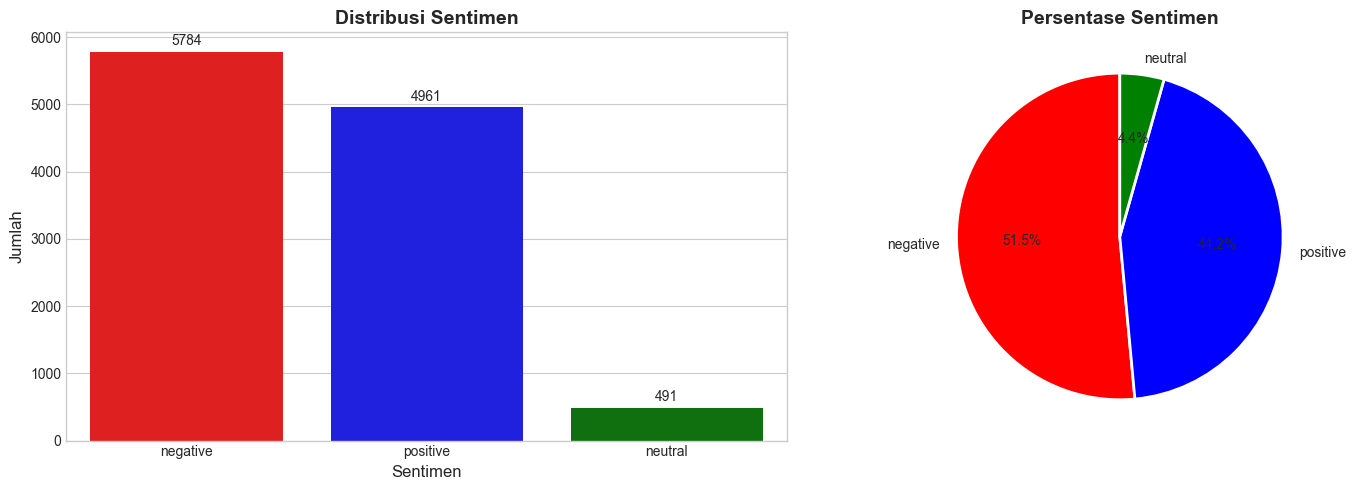

In [16]:
# Bar Chart & Pie Chart untuk setiap sentimen
plt.style.use("seaborn-v0_8-whitegrid")

sentiment_counts = clean_df['polarity'].value_counts()
colors = ['red','blue','green']

plt.figure(figsize=(15, 5))

# Bar Chart
plt.subplot(1, 2, 1)
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    palette=colors[:len(sentiment_counts)]
)
plt.title('Distribusi Sentimen', fontsize=14, weight="bold")
plt.xlabel('Sentimen', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=10)

# Pie Chart
plt.subplot(1, 2, 2)
explode = [0.03] * len(sentiment_counts)
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(sentiment_counts)],
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth': 2}
)
plt.title('Persentase Sentimen', fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

C:\Users\Alls\AppData\Local\Temp\ipykernel_19440\3763848792.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='jumlah', y='word', data=tfidf_df, palette="crest")


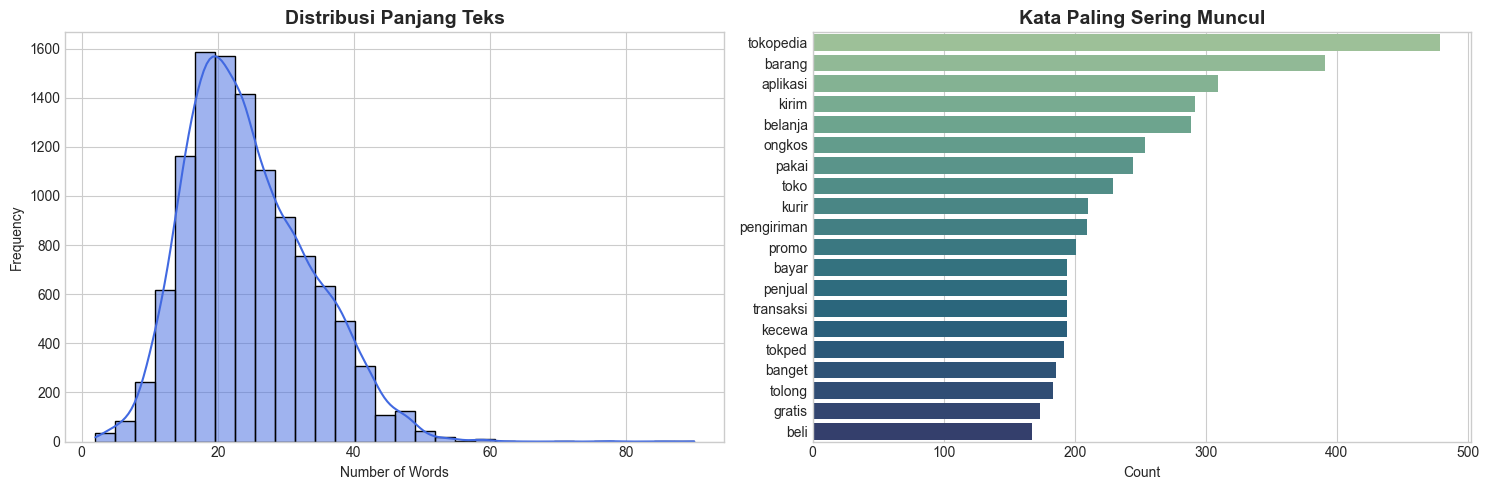

In [17]:
# Distribusi Panjang Teks dan Kata Paling Sering Muncul
plt.style.use("seaborn-v0_8-muted")
plt.figure(figsize=(15, 5))

# Distribusi panjang teks
plt.subplot(1, 2, 1)
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'], bins=30, kde=True, color="royalblue")
plt.title('Distribusi Panjang Teks', fontsize=14, weight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

# Kata paling sering Muncul
plt.subplot(1, 2, 2)
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df.columns = ['word', 'jumlah']
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)

sns.barplot(x='jumlah', y='word', data=tfidf_df, palette="crest")
plt.title('Kata Paling Sering Muncul', fontsize=14, weight='bold')
plt.xlabel('Count')
plt.ylabel('')

plt.tight_layout()
plt.show()

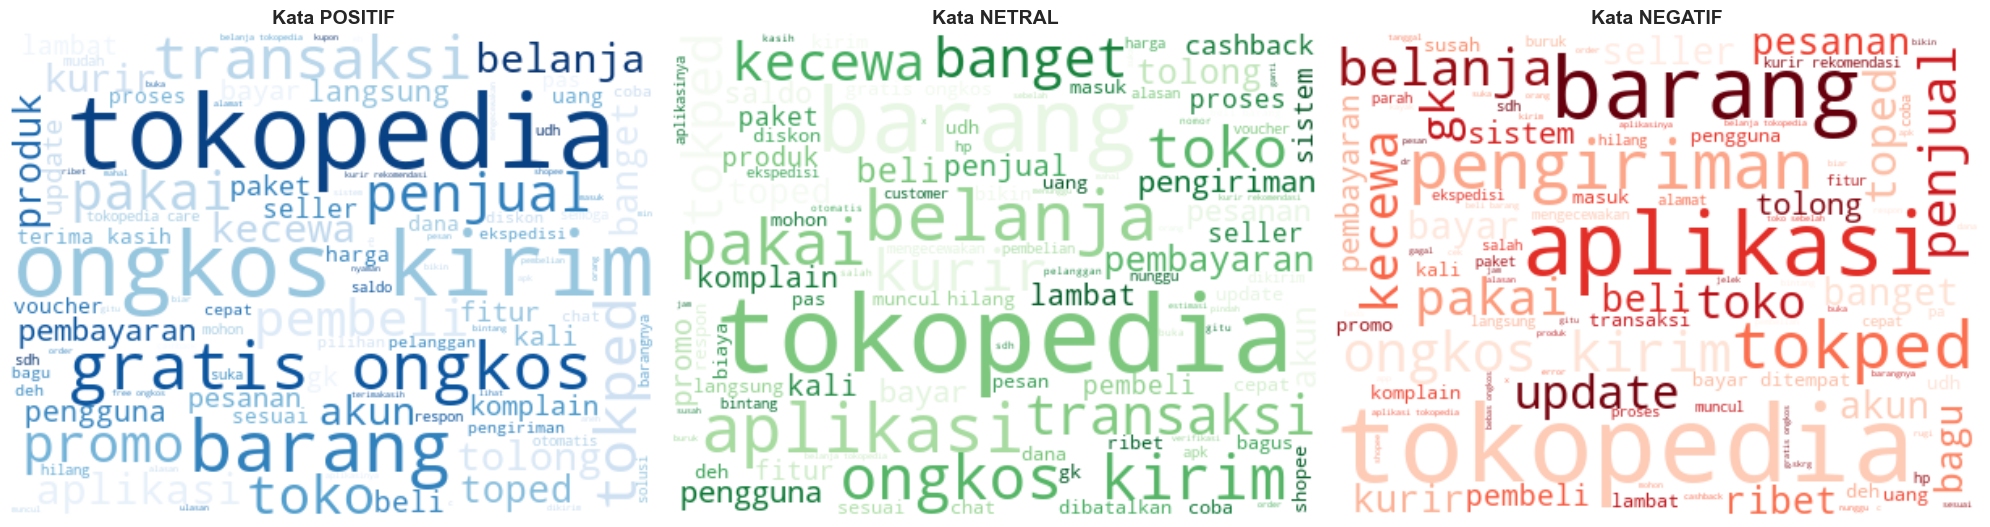

In [18]:
# Word Cloud untuk setiap sentimen
positive_text = ' '.join(clean_df[clean_df['polarity'] == 'positive']['text_akhir'])
neutral_text = ' '.join(clean_df[clean_df['polarity'] == 'neutral']['text_akhir'])
negative_text = ' '.join(clean_df[clean_df['polarity'] == 'negative']['text_akhir'])

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# Positive word cloud
wordcloud_pos = WordCloud(width=400, height=300, background_color='white', 
                         colormap='Blues', max_words=100).generate(positive_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Kata POSITIF', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Neutral word cloud
wordcloud_neu = WordCloud(width=400, height=300, background_color='white',
                         colormap='Greens', max_words=100).generate(neutral_text)
axes[1].imshow(wordcloud_neu, interpolation='bilinear')
axes[1].set_title('Kata NETRAL', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Negative word cloud
wordcloud_neg = WordCloud(width=400, height=300, background_color='white',
                         colormap='Reds', max_words=100).generate(negative_text)
axes[2].imshow(wordcloud_neg, interpolation='bilinear')
axes[2].set_title('Kata NEGATIF', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Data Modeling

In [19]:
# Melakukan balancing data sebelum ekstraksi fitur dengan smote yang cocok dalam kondisi ini
X = clean_df['text_akhir']
y = clean_df['polarity']

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

smote = SMOTE(random_state=42, sampling_strategy='auto')
X_resampled, y_resampled = smote.fit_resample(X_tfidf, y)

print("\nDistribusi kelas sesudah balancing (SMOTE):")
print(pd.Series(y_resampled).value_counts())


Distribusi kelas sesudah balancing (SMOTE):
polarity
negative    5784
positive    5784
neutral     5784
Name: count, dtype: int64


In [20]:
# EKSPERIMENT 1: TF-IDF + DEEP NEURAL NETWORK
label_mapping = {'negative': 0, 'positive': 1, 'neutral': 2}
y_encoded = pd.Series(y_resampled).map(label_mapping)

# Membagi data 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

model_smote_dnn = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model_smote_dnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Memasang early stop untuk optimasi
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_smote_dnn = model_smote_dnn.fit(
    X_train.toarray(), y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test.toarray(), y_test),
    callbacks=[early_stop],
    verbose=1
)

loss, accuracy = model_smote_dnn.evaluate(X_test.toarray(), y_test, verbose=0)

train_accuracy_smote_dnn = history_smote_dnn.history['accuracy'][-1]
test_accuracy_smote_dnn  = history_smote_dnn.history['val_accuracy'][-1]

print(f"\nAkurasi Training (SMOTE + DNN): {train_accuracy_smote_dnn:.4f}")
print(f"Akurasi Testing  (SMOTE + DNN): {test_accuracy_smote_dnn:.4f}")

c:\Users\Alls\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6919 - loss: 0.6477 - val_accuracy: 0.9121 - val_loss: 0.2194
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9507 - loss: 0.1370 - val_accuracy: 0.9306 - val_loss: 0.1858
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9852 - loss: 0.0450 - val_accuracy: 0.9262 - val_loss: 0.2291
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9931 - loss: 0.0200 - val_accuracy: 0.9205 - val_loss: 0.3363
Epoch 5/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9947 - loss: 0.0160 - val_accuracy: 0.9176 - val_loss: 0.3240
Epoch 6/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9964 - loss: 0.0107 - val_accuracy: 0.9306 - val_loss: 0.3239
Epoch 7/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9965 - loss: 0.0113 - val_accuracy: 0.9254 - val_loss: 0.3605

Akurasi Training (SMOTE + DNN): 0.9965
Akurasi Testing  (SMOTE + DNN): 0.9254


In [21]:
# Melakukan balancing data dengan random sampling yang cocok untuk kasus ini
X = clean_df[['text_akhir']]
y = clean_df['polarity']

ros = RandomOverSampler(random_state=42, sampling_strategy='auto')
X_resampled, y_resampled = ros.fit_resample(X, y)

clean_df_balanced = pd.DataFrame({
    'text_akhir': X_resampled['text_akhir'],
    'polarity': y_resampled
})

print("\nDistribusi kelas sesudah balancing (RandomOverSampler):")
print(clean_df_balanced['polarity'].value_counts())


Distribusi kelas sesudah balancing (RandomOverSampler):
polarity
negative    5784
positive    5784
neutral     5784
Name: count, dtype: int64


In [22]:
# EKSPERIMENT 2: WORD EMBEDDING + LSTM
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(clean_df_balanced['text_akhir'])

X_sequences = tokenizer.texts_to_sequences(clean_df_balanced['text_akhir'])
X_padded = pad_sequences(X_sequences, maxlen=100, padding='post', truncating='post')

# Melakukan labeling positive, negative, neutral
le = LabelEncoder()
y_balanced = clean_df_balanced['polarity']
y_enc = le.fit_transform(y_balanced)

# 70/30
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_padded, y_enc, test_size=0.3, random_state=42, stratify=y_enc
)

# Menggunakan lstm sebagai skema ke-2
model_lstm = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=64,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=[early_stop],
    verbose=1
)

train_accuracy_lstm = history_lstm.history['accuracy'][-1]
test_accuracy_lstm = history_lstm.history['val_accuracy'][-1]

print(f"\nAkurasi Training (Word Embedding + LSTM): {train_accuracy_lstm:.4f}")
print(f"Akurasi Testing (Word Embedding + LSTM): {test_accuracy_lstm:.4f}")

Epoch 1/30


c:\Users\Alls\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


190/190 ━━━━━━━━━━━━━━━━━━━━ 32s 138ms/step - accuracy: 0.6591 - loss: 0.7102 - val_accuracy: 0.8607 - val_loss: 0.3655
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 27s 140ms/step - accuracy: 0.9252 - loss: 0.2124 - val_accuracy: 0.9078 - val_loss: 0.2336
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.9714 - loss: 0.0828 - val_accuracy: 0.9101 - val_loss: 0.2987
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 26s 136ms/step - accuracy: 0.9853 - loss: 0.0487 - val_accuracy: 0.9122 - val_loss: 0.3341
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 26s 136ms/step - accuracy: 0.9901 - loss: 0.0322 - val_accuracy: 0.9166 - val_loss: 0.3309

Akurasi Training (Word Embedding + LSTM): 0.9901
Akurasi Testing (Word Embedding + LSTM): 0.9166


In [23]:
# EKSPERIMENT 3: CONV1D + WORD EMBEDDING
# 90/10
X_train_conv, X_test_conv, y_train_conv, y_test_conv = train_test_split(
    X_padded, y_enc, test_size=0.1, random_state=42, stratify=y_enc
)

# Menggunakan Convolutional Layer sebagai skema ke-3
model_conv = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model_conv.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Menyimpan informasi model
history_conv = model_conv.fit(
    X_train_conv, y_train_conv,
    epochs=30,
    batch_size=64,
    validation_data=(X_test_conv, y_test_conv),
    callbacks=[early_stop],
    verbose=1
)

train_accuracy_conv = history_conv.history['accuracy'][-1]
test_accuracy_conv = history_conv.history['val_accuracy'][-1]

print(f"\nAkurasi Training (CNN): {train_accuracy_conv:.4f}")
print(f"Akurasi Testing (CNN): {test_accuracy_conv:.4f}")

Epoch 1/30


c:\Users\Alls\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.6530 - loss: 0.6926 - val_accuracy: 0.8704 - val_loss: 0.2857
Epoch 2/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.9130 - loss: 0.2195 - val_accuracy: 0.9067 - val_loss: 0.2069
Epoch 3/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.9769 - loss: 0.0692 - val_accuracy: 0.9090 - val_loss: 0.2377
Epoch 4/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9930 - loss: 0.0241 - val_accuracy: 0.9130 - val_loss: 0.2957
Epoch 5/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9982 - loss: 0.0080 - val_accuracy: 0.9176 - val_loss: 0.3500

Akurasi Training (CNN): 0.9982
Akurasi Testing (CNN): 0.9176


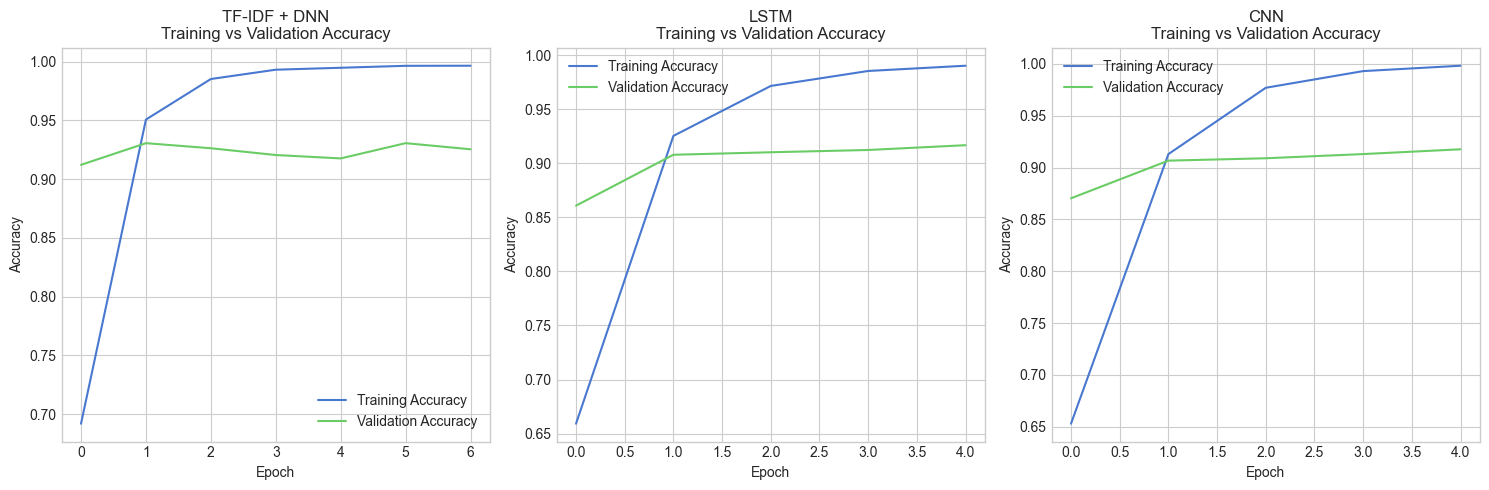

,Model,Training Accuracy,Testing Accuracy,Data Split,Feature Extraction
0,DNN,0.996470,0.925382,80/20,TF-IDF
1,LSTM,0.990120,0.916635,70/30,Word Embedding
2,CNN,0.998207,0.917627,90/10,Word Embedding


In [24]:
# Visualisasi hasil dari ketiga model
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_smote_dnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_smote_dnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('TF-IDF + DNN\nTraining vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM\nTraining vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_conv.history['accuracy'], label='Training Accuracy')
plt.plot(history_conv.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN\nTraining vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Ringkasan Tabel
results_summary = pd.DataFrame({
    'Model': ['DNN', 'LSTM', 'CNN'],
    'Training Accuracy': [train_accuracy_smote_dnn, train_accuracy_lstm, train_accuracy_conv],
    'Testing Accuracy': [test_accuracy_smote_dnn, test_accuracy_lstm, test_accuracy_conv],
    'Data Split': ['80/20', '70/30', '90/10'],
    'Feature Extraction': ['TF-IDF', 'Word Embedding', 'Word Embedding']
})

results_summary

Inference

In [25]:
# Pilih model terbaik berdasarkan akurasi testing
best_model_idx = np.argmax([test_accuracy_smote_dnn, test_accuracy_lstm, test_accuracy_conv])
best_models = [model_smote_dnn, model_lstm, model_conv]
best_model_names = ['TF-IDF + DNN', 'LSTM', 'CNN']
best_model = best_models[best_model_idx]
best_model_name = best_model_names[best_model_idx]

print(f"\nModel terbaik: {best_model_name}")

# Fungsi untuk preprocessing teks baru
def preprocess_text(text):
    text = cleaningText(text)
    text = casefoldingText(text)
    text = fix_slangwords(text)
    tokens = tokenizingText(text)
    tokens = filteringText(tokens)
    text = toSentence(tokens)
    return text

# Fungsi untuk prediksi sentimen
def predict_sentiment(text, model_type='tfidf'):
    processed_text = preprocess_text(text)
    
    if model_type == 'tfidf':
        # Untuk model TF-IDF
        text_vec = vectorizer.transform([processed_text])
        prediction = model_smote_dnn.predict(text_vec.toarray())
    else:
        # Untuk model LSTM/CNN
        sequence = tokenizer.texts_to_sequences([processed_text])
        padded_sequence = pad_sequences(sequence, maxlen=100, padding='post', truncating='post')
        prediction = model_lstm.predict(padded_sequence) if model_type == 'lstm' else model_conv.predict(padded_sequence)
    
    sentiment_idx = np.argmax(prediction)
    sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    confidence = np.max(prediction)
    
    return sentiment_map[sentiment_idx], confidence

# Contoh inferensi
test_samples = [
    "Aplikasi sangat bagus dan mudah digunakan!",
    "Aplikasi jelek, sering error dan lambat",
    "Aplikasi biasa saja, tidak ada yang spesial",
    "Tokopedia mantap! Pengiriman cepat dan barang sesuai",
    "Kecewa banget dengan pelayanan customer service",
    "Aplikasi cukup membantu untuk belanja online"
]

for i, sample in enumerate(test_samples, 1):
    sentiment, confidence = predict_sentiment(sample, 'lstm')  # menggunakan inferensi lstm
    print(f"{i}. Teks: {sample}")
    print(f"   Sentimen: {sentiment} (Confidence: {confidence:.4f})")
    print()


Model terbaik: TF-IDF + DNN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
1. Teks: Aplikasi sangat bagus dan mudah digunakan!
   Sentimen: negative (Confidence: 0.6158)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2. Teks: Aplikasi jelek, sering error dan lambat
   Sentimen: negative (Confidence: 0.9103)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
3. Teks: Aplikasi biasa saja, tidak ada yang spesial
   Sentimen: negative (Confidence: 0.5526)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
4. Teks: Tokopedia mantap! Pengiriman cepat dan barang sesuai
   Sentimen: positive (Confidence: 0.4117)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
5. Teks: Kecewa banget dengan pelayanan customer service
   Sentimen: neutral (Confidence: 0.7975)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
6. Teks: Aplikasi cukup membantu untuk belanja online
   Sentimen: negative (Confidence: 0.7656)

